# Results Visualization

In this notebook we demonstrate how to simulate a single test signal,
run the trained `SquigNet` model on it, and visualize both the raw
signal and the predicted base calls.  Each section is described with
professional headers and clear explanations.

In [1]:
# imports
import sys
from pathlib import Path

# ensure src on path
ROOT = Path('..').resolve()
SRC = str(ROOT / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import torch
import matplotlib.pyplot as plt

from data_simulator import generate_squiggle, standardize_signal
from architecture import SquigNet
from inference import greedy_decode, run_inference, load_model

## Signal Generation

We generate a single random DNA sequence, simulate the nanopore
squiggle signal associated with it, and standardize the result.  The
signal will later be fed into the network.

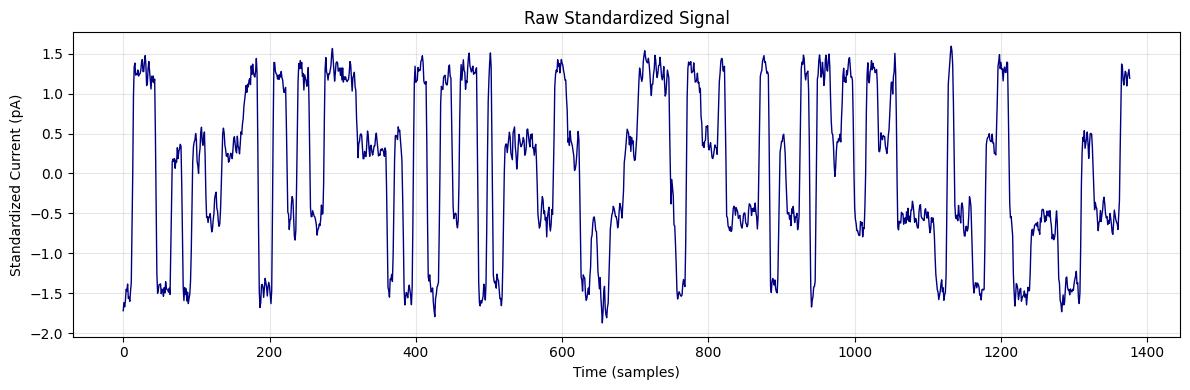

In [2]:
import numpy as np

# create a short random sequence
seq_len = np.random.randint(50, 101)
dna_sequence = ''.join(np.random.choice(['A','C','G','T'], seq_len))

raw_signal, dwell_times = generate_squiggle(dna_sequence)
signal = standardize_signal(raw_signal)

# plot raw signal
plt.figure(figsize=(12,4))
plt.plot(signal, color='navy', linewidth=1)
plt.title('Raw Standardized Signal')
plt.xlabel('Time (samples)')
plt.ylabel('Standardized Current (pA)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Model Inference

Load the pre-trained `SquigNet` model from disk and run a forward pass on
the generated signal.  A greedy decoder converts the network logits to a
DNA string.

In [5]:
# load model
model_path = Path('../models/squig_model.pt')
model = load_model(model_path, torch.device('cpu'))

# run inference
logits = run_inference(model, signal)
predicted_string = greedy_decode(logits)

print(f"Target sequence:    {dna_sequence}")
print(f"Predicted sequence: {predicted_string}")

Target sequence:    TGGTTCTCACCGTGAGAGGGCCCTCTGTGAGGTGTCCCAGCTATACGGGATGGCCGAAAGTCAGTGCGAGCGAAATGAATCGATTAAATTCAAG
Predicted sequence: TGGTCTCACCGTGAGAGGGCCCTCTGTGAGGTGTCCCAAGCTATACGGGATGCGAAAGTCAGTGCGAGCGAAATGAATCGATTAATTCAAG


## Basecall Overlay Visualization

Overlay the predicted bases on the signal.  Each base is placed at the
center of its dwell region.  Correct calls are colored green and
incorrect ones red for quick visual assessment.

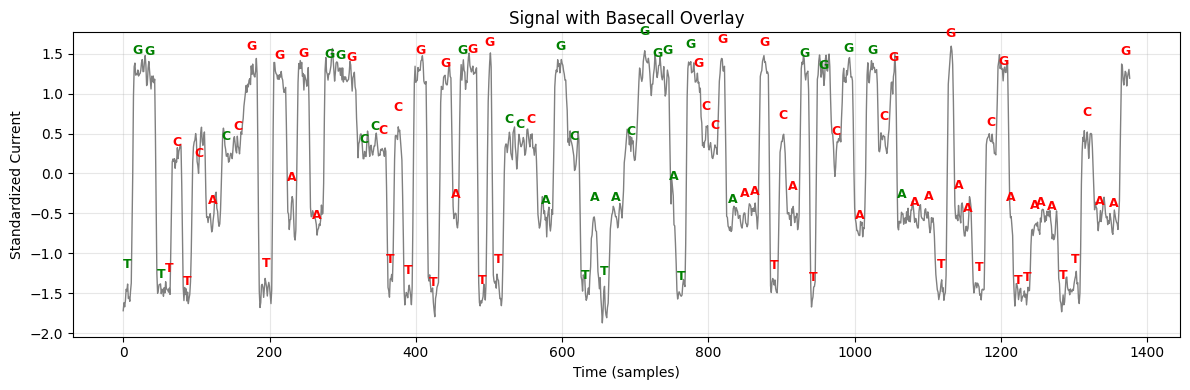

In [6]:
# compute dwell centers
cumulative = np.cumsum([0] + dwell_times)
positions = [int(cumulative[i] + dwell_times[i]/2) for i in range(len(dwell_times))]

# align prediction to target naive (assumes equal length)
matches = set(i for i,(a,b) in enumerate(zip(dna_sequence, predicted_string)) if a==b)

plt.figure(figsize=(12,4))
plt.plot(signal, color='grey', linewidth=1)
for i,pos in enumerate(positions):
    if i >= len(dna_sequence): break
    base = dna_sequence[i]
    color = 'green' if i in matches else 'red'
    plt.text(pos, signal[pos]+0.2, base, color=color,
             fontsize=9, fontweight='bold', ha='center')

plt.title('Signal with Basecall Overlay')
plt.xlabel('Time (samples)')
plt.ylabel('Standardized Current')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()